In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_parquet(
    "C:\\Users\\Mateus Monteleone\\Projects\\ic\\data\\tweets_rotulados.parquet",
    
)

In [7]:
df.head()

,full_text,clean_text,is_economic,sentiment_manual
0,Única coisa que o bozó pode fazer é liberar um...,Única coisa que o bozó pode fazer é liberar um...,1,1.0
1,@LulaOficial @fbbreal Lula perde e Fátima perd...,@USER @USER Lula perde e Fátima perderá o empr...,1,-1.0
2,Bolsonaro colocou o pobre no lixo o valor só p...,Bolsonaro colocou o pobre no lixo o valor só p...,1,-1.0
3,Fiz questão de assinar a Carta Compromisso pel...,Fiz questão de assinar a Carta Compromisso pel...,1,1.0
4,"@paulonbjr Brincou, né? Só tem essa nas mãos d...","@USER Brincou , né ? Só tem essa nas mãos de q...",1,-1.0


Resumo descritivo da coluna 'sentiment_manual':
count    400.000000
mean      -0.075000
std        0.881088
min       -1.000000
25%       -1.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: sentiment_manual, dtype: float64

Frequência de cada rótulo:
sentiment_manual
-1.0    171
 0.0     88
 1.0    141
Name: count, dtype: int64

Quartis e extremos:
Min: -1.0
1º Quartil (Q1): -1.0
Mediana (Q2): 0.0
3º Quartil (Q3): 1.0
Max: 1.0

Média: -0.07
Desvio padrão: 0.88


C:\Users\Mateus Monteleone\AppData\Local\Temp\ipykernel_3484\3012993455.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=labels_mapped, palette={"Negativo":"#d73027", "Neutro":"#fee08b", "Positivo":"#1a9850"})


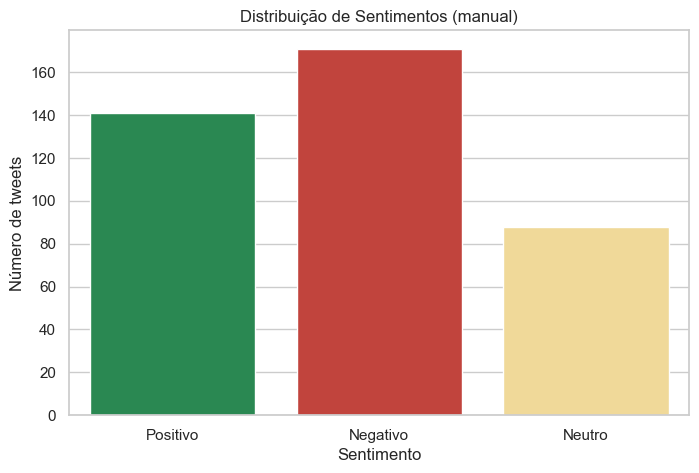

In [15]:
# Remove valores NA, se houver
labels = df['sentiment_manual'].dropna()

# Estatísticas descritivas
print("Resumo descritivo da coluna 'sentiment_manual':")
print(labels.describe())

# Frequência de cada rótulo
frequencias = labels.value_counts().sort_index()
print("\nFrequência de cada rótulo:")
print(frequencias)

# Quartis e extremos
quartis = np.percentile(labels, [0, 25, 50, 75, 100])
print("\nQuartis e extremos:")
print(f"Min: {quartis[0]}")
print(f"1º Quartil (Q1): {quartis[1]}")
print(f"Mediana (Q2): {quartis[2]}")
print(f"3º Quartil (Q3): {quartis[3]}")
print(f"Max: {quartis[4]}")

# Média e desvio padrão
media = labels.mean()
desvio = labels.std()
print(f"\nMédia: {media:.2f}")
print(f"Desvio padrão: {desvio:.2f}") 

# Mapear valores para rótulos mais claros
labels_mapped = df['sentiment_manual'].dropna().map({-1: "Negativo", 0: "Neutro", 1: "Positivo"})

sns.set(style="whitegrid")

cores = {"Negativo":"#d73027", "Neutro":"#fee08b", "Positivo":"#1a9850"}

# Histograma estilizado
plt.figure(figsize=(8,5))
sns.countplot(x=labels_mapped, palette={"Negativo":"#d73027", "Neutro":"#fee08b", "Positivo":"#1a9850"})
plt.xlabel("Sentimento")
plt.ylabel("Número de tweets")
plt.title("Distribuição de Sentimentos (manual)")
plt.show()